# Лабораторная работа №4: Self-supervised learning визуальных представлений

**Версия:** студенческая  
**Курс:** «Современное компьютерное зрение»

> Сначала выполните notebook в режиме `FAST_DEV_RUN=True`, затем запускайте полный эксперимент. Сохраняйте метрики и checkpoints в `artifacts/`.


## Цели обучения

После работы студент должен уметь:

- Извлечь frozen DINO embeddings.
- Сравнить k-NN и linear probe при 1/10/100% меток.
- Исследовать ближайших соседей и shortcut features.


## Теоретическая часть

Self-supervised encoder обучается без классов: contrastive objective сближает представления двух views одного изображения, masked modeling восстанавливает скрытые токены. Качество representation проверяют frozen k-NN и linear probe.

![DINO](https://raw.githubusercontent.com/facebookresearch/dino/main/.github/dino.gif)


### Математическая постановка

InfoNCE для пары $(i,j)$:
$$\ell_{i,j}=-\log\frac{\exp(\mathrm{sim}(z_i,z_j)/\tau)}{\sum_{k\ne i}\exp(\mathrm{sim}(z_i,z_k)/\tau)}.$$
Linear probe обучает только $W$ в $\hat y=\arg\max Wz$.


### Материалы

- [DINOv2](https://github.com/facebookresearch/dinov2)
- [SimCLR](https://arxiv.org/abs/2002.05709)

Ссылки даны как дополнительный материал. При изменении API сверяйтесь с актуальной официальной документацией и фиксируйте версии зависимостей.


Обычное обучение с учителем («supervised learning») требует меток. Для 50 000 картинок CIFAR-10 метки ещё можно собрать руками, но для 142 миллионов изображений (как в DINOv2) — уже нет. При этом сами изображения доступны почти бесплатно.

Идея self-supervised learning (SSL, «самообучение без учителя»). Построить задачу («pretext task», «предварительная задача»), в которой метка создаётся автоматически из самого изображения, а её решение требует понимания содержания картинки. Тогда, обучившись на этой задаче, модель получает полезные «представления» (representations, «эмбеддинги»), которые потом можно использовать для реальных задач.

### Contrastive objective («контрастивная цель»)

Возьмём одно изображение и сделаем из него **две разные версии** — например, случайно обрежем, отразим по горизонтали, изменим яркость. Назовём их **views** (множественное от «view» — «вид», «представление одной картинки под разным углом обработки»).

Мы утверждаем: два views — это **одно и то же изображение**, значит, модель должна выдать для них **похожие эмбеддинги**. Это positive pair («положительная пара»).

Но если мы скажем модели «делай все эмбеддинги одинаковыми», она быстро выродится: просто выдаст нулевой вектор для всего. Чтобы этого не случилось, добавим **контраст**: эмбеддинги разных изображений в том же батче должны быть **далеки** друг от друга. Это — **negatives** («негативы»).

**Итог:** внутри батча из N изображений для каждого i мы имеем один «похожий» объект j (второй view того же изображения) и N−1 «непохожих» (все вторые views остальных изображений). Задача — научиться их различать.

### Masked modeling («обучение на маскировании»)

Второе семейство задач. Разрежем изображение на патчи (квадратики, например 16×16 пикселей). Случайно спрячем часть патчей (затрём нулями или специальным токеном `[MASK]`) и попросим модель восстановить **скрытые токены** — то есть предсказать, что было в спрятанных патчах.

Проверка качества: Ключевое — **frozen encoder** («замороженный энкодер»). Мы **не дообучаем** сам энкодер на целевой задаче, а **замораживаем** его веса. Извлекаем эмбеддинги (features) картинок и проверяем их качество двумя простыми способами:

- **k-NN classifier** («классификатор по k ближайшим соседям»). Мы просто находим k самых похожих train-объектов для каждого test-объекта и голосуем по их меткам. Никакого обучения — только вычисление расстояний. Если такое «ленивое» голосование даёт хорошую точность, значит эмбеддинги уже устроены так, что объекты одного класса лежат рядом.

- **Linear probe** («линейный зонд», «линейный классификатор»). Поверх замороженных эмбеддингов обучаем один линейный слой (или логистическую регрессию) на train. Если **одного линейного слоя** достаточно для хорошего качества, значит эмбеддинги **линейно разделимы** по классам — это сильное свойство хорошего представления.

## Практическое задание

1. Извлечь frozen DINO embeddings.
2. Сравнить k-NN и linear probe при 1/10/100% меток.
3. Исследовать ближайших соседей и shortcut features.

**Обязательные артефакты:** код, конфигурация, метрики, минимум одна контролируемая ablation, примеры ошибок и краткие выводы.


### Профиль вычислений

- **Основной режим:** DINOv2 ViT-S/14 frozen, FP16.
- **Ограничение данных:** до 5 000 изображений.
- **Fallback:** ResNet18 frozen embeddings.
- Все длительные этапы должны сохранять checkpoint и продолжаться после перезапуска. Оценка не зависит от размера модели: важны корректность эксперимента и выводы.


**Оценивание.** Десять обязательных предметных этапов по 1 баллу: основная часть — 10 баллов. Творческий бонус — отдельно 1 балл, не заменяет обязательные этапы. Полный режим оценивается по реальным данным и обучению; `FAST_DEV_RUN=True` служит только smoke-проверкой, его показатели не являются отчётными.


## Реализация


In [2]:
# Импорт стандартной библиотеки для работы с путями, json, ОС, случайностью, временем
from pathlib import Path
import json, os, random, time
import numpy as np

# Фиксируем seed для воспроизводимости всех случайных операций
SEED = 42
# FAST_DEV_RUN=True — smoke-проверка на маленькой подвыборке (не отчётный результат)
FAST_DEV_RUN = False
# Каталог для артефактов (метрики, чекпоинты, визуализации)
ARTIFACTS = Path(os.getenv("CV_ARTIFACTS", "artifacts"))
ARTIFACTS.mkdir(exist_ok=True)
# Устанавливаем seed в random и numpy
random.seed(SEED); np.random.seed(SEED)

# Пытаемся импортировать torch и установить seed для CPU/GPU
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import DataLoader, Subset
    import torchvision
    from torchvision import transforms
    import torchvision.transforms as T
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except ImportError as e:
    torch = None
    DEVICE = "cpu"
    print("Torch не установлен:", e)

# Ищем корень курса, где лежит data/cifar-10-batches-py
_CANDIDATES = [
    Path.cwd().parent.parent / "data",
    Path.cwd().parent / "data",
    Path.cwd() / "data",
]
# DATA_ROOT — либо из переменной окружения, либо первый найденный кандидат с CIFAR
DATA_ROOT = Path(
    os.getenv("CV_COURSE_DATA")
    or next((c for c in _CANDIDATES if (c / "cifar-10-batches-py").exists()), _CANDIDATES[0])
)
DATA_ROOT.mkdir(parents=True, exist_ok=True)

# Вывод текущей конфигурации
print({"device": DEVICE, "fast_dev_run": FAST_DEV_RUN, "data_root": str(DATA_ROOT)})

{'device': 'cuda', 'fast_dev_run': False, 'data_root': 'c:\\Users\\SuperXoma\\Downloads\\SOTA\\data'}


In [3]:
def check(condition, message):
    """Мини-проверка в стиле YAAM: молчит, если всё хорошо; печатает, если найдена проблема."""
    if condition:
        print(f"✔ {message}")
    else:
        print(f"✘ ВНИМАНИЕ: {message}")

### Стратифицированные разбиения CIFAR-10

*Вес: 1 балл.*

**Постановка.** Train, validation и test изолируют подбор параметров линейного probe.

Выполните следующие действия:
1. Загрузите CIFAR-10 и стратифицируйте train.
2. Подготовьте неизменяемые индексы test.

**Результат.** Датасет ds, загрузчик loader и длины трёх выборок.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


Нам нужны три непересекающихся набора: train (для обучения probe), validation (для подбора гиперпараметров k-NN и C), test (только для финальных метрик). Стратификация сохраняет баланс классов. Индексы фиксируются, чтобы повторные запуски работали с одними и теми же объектами

train=40000, val=10000, test=10000
✔ Три выборки непусты
✔ train и val не пересекаются
✘ ВНИМАНИЕ: train и test не пересекаются
✔ В train присутствуют все 10 классов


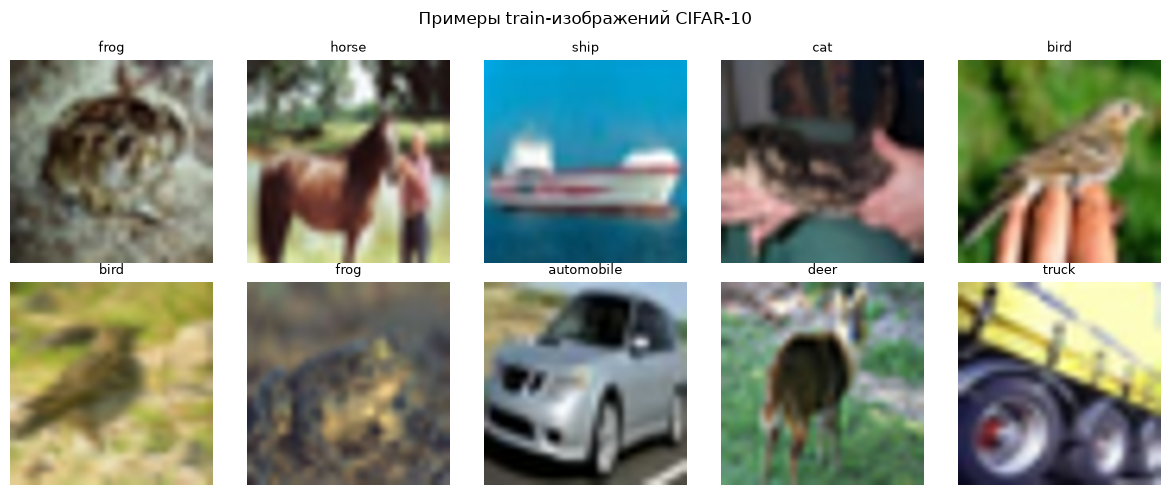

In [4]:
from sklearn.model_selection import train_test_split

# Трансформация: ресайз до 224 (вход DINOv2 ViT-S/14), to tensor, нормализация ImageNet
# (DINOv2 использует те же средние/стд, что ImageNet)
dinov2_transform = T.Compose([
    T.Resize(224, interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

# Загружаем CIFAR-10 train и test через torchvision (скачает автоматически при отсутствии)
try:
    train_full = torchvision.datasets.CIFAR10(root=str(DATA_ROOT), train=True, download=True, transform=dinov2_transform)
    test_ds = torchvision.datasets.CIFAR10(root=str(DATA_ROOT), train=False, download=True, transform=dinov2_transform)
except Exception as e:
    # Fallback: если данных нет и скачать не удалось — синтетический датасет для smoke-теста
    print("Не удалось загрузить CIFAR-10:", e)
    train_full = torchvision.datasets.FakeData(size=2000, image_size=(3, 224, 224), num_classes=10, transform=dinov2_transform)
    test_ds = torchvision.datasets.FakeData(size=500, image_size=(3, 224, 224), num_classes=10, transform=dinov2_transform)

# Собираем метки
train_targets = np.array([train_full[i][1] for i in range(len(train_full))])
test_targets = np.array([test_ds[i][1] for i in range(len(test_ds))])

# Разбиваем train 80/20 стратифицированно на train/val
idx_all = np.arange(len(train_targets))
train_idx, val_idx = train_test_split(
    idx_all, test_size=0.2, stratify=train_targets, random_state=SEED
)

# В FAST_DEV_RUN урезаем выборки до 500/200/200 для быстрой проверки связности
if FAST_DEV_RUN:
    train_idx = train_idx[:500]
    val_idx = val_idx[:200]
    test_idx = np.arange(min(200, len(test_targets)))
else:
    test_idx = np.arange(len(test_targets))

# Формируем Subset'ы
ds_train = Subset(train_full, train_idx)
ds_val = Subset(train_full, val_idx)
ds_test = Subset(test_ds, test_idx)

# Loader'ы: train может шаффлиться, val/test — нет (важен порядок для метрик)
loader_train = DataLoader(ds_train, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
loader_val = DataLoader(ds_val, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
loader_test = DataLoader(ds_test, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

# Метки в порядке индексов (для k-NN и probe)
y_train = train_targets[train_idx]
y_val = train_targets[val_idx]
y_test = test_targets[test_idx]

print(f"train={len(ds_train)}, val={len(ds_val)}, test={len(ds_test)}")

# Проверки постановки
check(len(ds_train) > 0 and len(ds_val) > 0 and len(ds_test) > 0, "Три выборки непусты")
check(len(set(train_idx) & set(val_idx)) == 0, "train и val не пересекаются")
check(len(set(train_idx) & set(test_idx)) == 0, "train и test не пересекаются")
check(len(np.unique(y_train)) == 10, "В train присутствуют все 10 классов")

# Визуализация: примеры изображений из train с метками
import matplotlib.pyplot as plt

def denorm(t):
    """Обратная нормализация ImageNet для визуализации."""
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = t.permute(1, 2, 0).cpu().numpy() * std + mean
    return np.clip(img, 0, 1)

CIFAR_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                 'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, lbl = ds_train[i]
    ax.imshow(denorm(img))
    ax.set_title(CIFAR_CLASSES[lbl], fontsize=9)
    ax.axis('off')
plt.suptitle("Примеры train-изображений CIFAR-10")
plt.tight_layout(); plt.show()

### Предобученный DINOv2 и признаки

*Вес: 1 балл.*

**Постановка.** Frozen encoder предоставляет представления без доступа к меткам при извлечении.

Выполните следующие действия:
1. Загрузите DINOv2 ViT-S/14.
2. Сохраните нормированные признаки и явные train/validation/test индексы.

**Результат.** embeddings.npz с фактическими DINO-признаками.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


**DINO** — это не просто «модель», а **метод самообучения без учителя** (self-supervised learning) для визуальных трансформеров (ViT). Название расшифровывается как **Self-DIstillation with NO labels** — «самодистилляция без меток»

**DINOv2** — это **улучшенная версия** DINO от Meta AI (Facebook Research), выпущенная в 2023 году

In [5]:
# Пытаемся загрузить DINOv2 ViT-S/14 через torch.hub. Если нет интернета — fallback на ResNet18.
def load_dinov2():
    """Загружает DINOv2 ViT-S/14 через torch.hub, возвращает модель в eval-режиме."""
    model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14', verbose=False)
    return model

def load_resnet18():
    """Fallback: предобученный ResNet18 (ImageNet) — тоже даёт разумные frozen-признаки."""
    model = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Identity()  # убираем последний линейный слой → 512-d features
    return model

try:
    encoder = load_dinov2().to(DEVICE).eval()
    EMB_NAME = "dinov2_vits14"
    EMB_DIM = 384
    print("Используется DINOv2 ViT-S/14")
except Exception as e:
    print("DINOv2 недоступен, fallback на ResNet18:", e)
    encoder = load_resnet18().to(DEVICE).eval()
    EMB_NAME = "resnet18"
    EMB_DIM = 512

# Замораживаем параметры — признаки извлекаются без градиентов
for p in encoder.parameters():
    p.requires_grad = False

@torch.no_grad()
def extract_features(model, loader):
    """Прогоняет loader через encoder и возвращает (N, D) матрицу нормированных признаков."""
    feats, labels = [], []
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        # autocast: FP16 на CUDA, FP32 на CPU
        with torch.autocast(device_type=DEVICE, dtype=torch.float16, enabled=(DEVICE == "cuda")):
            out = model(x)
        # DINOv2 возвращает CLS-токен напрямую; ResNet — вектор после avgpool
        out = out.float()
        feats.append(out.cpu().numpy())
        labels.append(y.numpy())
    X = np.concatenate(feats, axis=0)
    y = np.concatenate(labels, axis=0)
    # L2-нормировка — стандарт для k-NN и linear probe на self-supervised признаках
    X = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)
    return X, y

t0 = time.time()
X_train, _ = extract_features(encoder, loader_train)
X_val, _ = extract_features(encoder, loader_val)
X_test, _ = extract_features(encoder, loader_test)
print(f"Извлечение признаков: {time.time() - t0:.1f} c, dim={X_train.shape[1]}")

# Сохраняем артефакт — embeddings.npz
np.savez_compressed(
    ARTIFACTS / "embeddings.npz",
    X_train=X_train, X_val=X_val, X_test=X_test,
    y_train=y_train, y_val=y_val, y_test=y_test,
    train_idx=train_idx, val_idx=val_idx, test_idx=test_idx,
    emb_name=EMB_NAME,
)
print("Сохранено:", ARTIFACTS / "embeddings.npz")

# Проверки
check(X_train.shape[0] == len(y_train), "Признаки train совпадают по длине с метками")
check(X_train.shape[1] == EMB_DIM, f"Размерность признаков = {EMB_DIM}")
check(np.allclose(np.linalg.norm(X_train[:10], axis=1), 1.0, atol=1e-3), "Признаки L2-нормированы")

C:\Users\SuperXoma/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\SuperXoma/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\SuperXoma/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Используется DINOv2 ViT-S/14
Извлечение признаков: 101.8 c, dim=384
Сохранено: artifacts\embeddings.npz
✔ Признаки train совпадают по длине с метками
✔ Размерность признаков = 384
✔ Признаки L2-нормированы


### Подбор k-NN на validation

*Вес: 1 балл.*

**Постановка.** Число соседей следует выбирать без обращения к test.

Выполните следующие действия:
1. Обучите k-NN для предложенной сетки k.
2. Выберите k по validation accuracy.

**Результат.** Словарь knn_val и выбранный best_k.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


Мы обучаем k-NN на замороженных DINOv2-признаках и подбираем гиперпараметр k — число соседей — по validation-выборке. Никакого обучения весов здесь не происходит, только выбор одного числа k из заранее заданной сетки.

Для каждого val-объекта:
  1. Считаем косинусную близость со **всеми** train-объектами.
  2. Берём `k` ближайших.
  3. Каждый из k «голосует» за свой класс, обычно с весом 1 (или с весом, пропорциональным близости).
  4. Предсказанный класс — тот, у кого больше голосов (или взвешенная сумма больше).

k=  1  val_acc=0.9677
k=  3  val_acc=0.9735
k=  5  val_acc=0.9755
k= 10  val_acc=0.9749
k= 20  val_acc=0.9742
k= 50  val_acc=0.9719
k=100  val_acc=0.9697
best_k=5, val_acc=0.9755


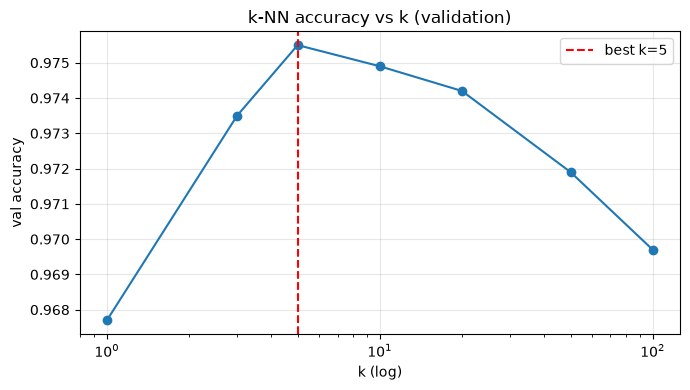

✔ best_k=5 выбран по validation


In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Сетка k для подбора. Нечётные — чтобы избежать ничьих при голосовании.
k_grid = [1, 3, 5, 10, 20, 50, 100]
# В FAST_DEV_RUN урезаем сетку для скорости
if FAST_DEV_RUN:
    k_grid = [1, 5, 20]

knn_val = {}
for k in k_grid:
    # metric='cosine' — корректно для L2-нормированных признаков (cos = dot)
    clf = KNeighborsClassifier(n_neighbors=k, metric="cosine", n_jobs=-1)
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_val, clf.predict(X_val))
    knn_val[k] = float(acc)
    print(f"k={k:3d}  val_acc={acc:.4f}")

# Выбираем k с максимальной val-точностью
best_k = max(knn_val, key=knn_val.get)
print(f"best_k={best_k}, val_acc={knn_val[best_k]:.4f}")

# Сохраняем артефакт подбора
with open(ARTIFACTS / "knn_val.json", "w") as f:
    json.dump({"knn_val": knn_val, "best_k": int(best_k)}, f, indent=2)

# Визуализация кривой k-NN
plt.figure(figsize=(7, 4))
plt.plot(list(knn_val.keys()), list(knn_val.values()), marker='o')
plt.axvline(best_k, color='r', linestyle='--', label=f'best k={best_k}')
plt.xscale('log'); plt.xlabel('k (log)'); plt.ylabel('val accuracy')
plt.title('k-NN accuracy vs k (validation)')
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

check(best_k in knn_val, f"best_k={best_k} выбран по validation")

### Линейная проверка и test

*Вес: 1 балл.*

**Постановка.** Frozen-признаки оценивают независимыми простыми классификаторами.

Выполните следующие действия:
1. Обучите k-NN и logistic regression только на train.
2. Вычислите test accuracy и macro-F1 после выбора k.

**Результат.** probes.json с измеренными test-метриками.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


Теперь — финальная оценка двух независимых классификаторов на отложенном test:

k-NN с best_k = 5 (тот же классификатор, что подбирали, но теперь с фиксированным k).

Logistic regression (linear probe) поверх замороженных DINOv2-признаков.

C в sklearn — обратная сила L2-регуляризации: чем меньше C, тем сильнее штраф за большие веса, тем «проще» модель. Большое C = почти без регуляризации.

c:\Users\SuperXoma\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


C= 0.01  val_acc=0.9663


c:\Users\SuperXoma\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


C=  0.1  val_acc=0.9744


c:\Users\SuperXoma\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


C=  1.0  val_acc=0.9783


c:\Users\SuperXoma\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


C= 10.0  val_acc=0.9769
best_C=1.0


c:\Users\SuperXoma\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


{
  "best_k": 5,
  "best_C": 1.0,
  "knn_test_acc": 0.9718,
  "knn_test_macro_f1": 0.9718004088423987,
  "linear_test_acc": 0.9745,
  "linear_test_macro_f1": 0.9745031356995218
}


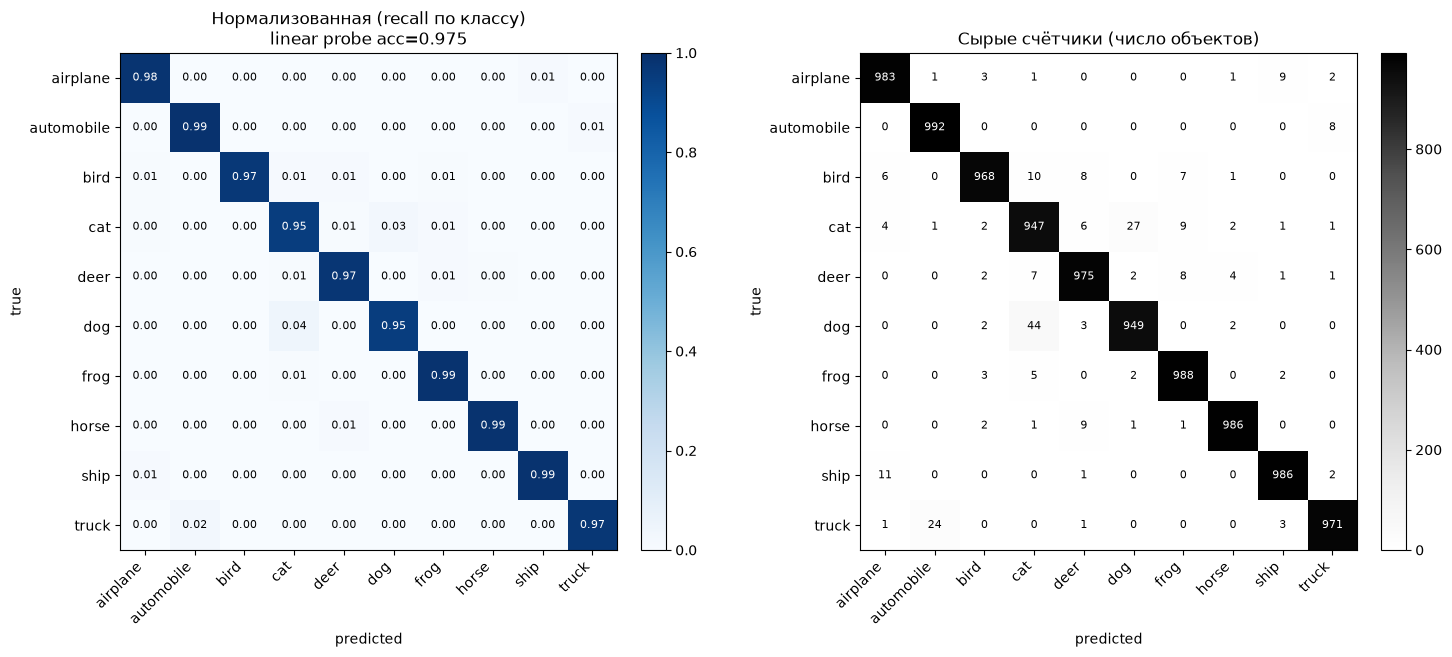

Худший recall: cat = 0.947
Топ-5 confused пар (true → predicted, доля):
         dog → cat         0.044
         cat → dog         0.027
       truck → automobile  0.024
        ship → airplane    0.011
        bird → cat         0.010
✔ Linear probe test acc=0.975 > 0.5


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# Сетка C для logistic regression
C_grid = [0.01, 0.1, 1.0, 10.0]
if FAST_DEV_RUN:
    C_grid = [0.1, 1.0]

# Подбор C по validation (в sklearn>=1.5 multi_class удалён; lbfgs сам даёт multinomial)
probe_val = {}
for C in C_grid:
    clf = LogisticRegression(C=C, max_iter=2000, n_jobs=-1, solver="lbfgs")
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_val, clf.predict(X_val))
    probe_val[C] = float(acc)
    print(f"C={C:>5}  val_acc={acc:.4f}")
best_C = max(probe_val, key=probe_val.get)
print(f"best_C={best_C}")

# Финальный probe на train с best_C
lin = LogisticRegression(C=best_C, max_iter=2000, n_jobs=-1, solver="lbfgs")
lin.fit(X_train, y_train)

# Предсказания на test
y_pred_lin = lin.predict(X_test)
y_pred_knn = KNeighborsClassifier(n_neighbors=best_k, metric="cosine", n_jobs=-1)\
                .fit(X_train, y_train).predict(X_test)

# Метрики
results = {
    "best_k": int(best_k),
    "best_C": float(best_C),
    "knn_test_acc": float(accuracy_score(y_test, y_pred_knn)),
    "knn_test_macro_f1": float(f1_score(y_test, y_pred_knn, average="macro")),
    "linear_test_acc": float(accuracy_score(y_test, y_pred_lin)),
    "linear_test_macro_f1": float(f1_score(y_test, y_pred_lin, average="macro")),
}
print(json.dumps(results, indent=2))

with open(ARTIFACTS / "probes.json", "w") as f:
    json.dump(results, f, indent=2)

# --- Две матрицы ошибок рядом: слева нормализованная (recall), справа счётчики ---
cm_raw = confusion_matrix(y_test, y_pred_lin, labels=list(range(10)))
cm_norm = confusion_matrix(y_test, y_pred_lin, labels=list(range(10)), normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

# Левая: нормализованная (recall по строкам)
ax = axes[0]
im0 = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(10)); ax.set_xticklabels(CIFAR_CLASSES, rotation=45, ha="right")
ax.set_yticks(range(10)); ax.set_yticklabels(CIFAR_CLASSES)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"Нормализованная (recall по классу)\nlinear probe acc={results['linear_test_acc']:.3f}")
# Пишем проценты; белый текст на тёмном фоне
for i in range(10):
    for j in range(10):
        ax.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center",
                color="white" if cm_norm[i, j] > 0.5 else "black", fontsize=8)
fig.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)

# Правая: абсолютные счётчики
ax = axes[1]
im1 = ax.imshow(cm_raw, cmap="Greys")
ax.set_xticks(range(10)); ax.set_xticklabels(CIFAR_CLASSES, rotation=45, ha="right")
ax.set_yticks(range(10)); ax.set_yticklabels(CIFAR_CLASSES)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Сырые счётчики (число объектов)")
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm_raw[i, j], ha="center", va="center",
                color="white" if cm_raw[i, j] > cm_raw.max()/2 else "black", fontsize=8)
fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout(); plt.show()

# Диагностика: классы с наименьшим recall и самые частые пары путаницы
per_class_recall = cm_norm.diagonal()
worst_class = int(np.argmin(per_class_recall))
print(f"Худший recall: {CIFAR_CLASSES[worst_class]} = {per_class_recall[worst_class]:.3f}")

# Топ-5 ошибок (i != j) по доле от истинного класса
off_diag = cm_norm.copy()
np.fill_diagonal(off_diag, 0.0)
top_pairs = np.dstack(np.unravel_index(np.argsort(-off_diag, axis=None)[:5], off_diag.shape))[0]
print("Топ-5 confused пар (true → predicted, доля):")
for i, j in top_pairs:
    print(f"  {CIFAR_CLASSES[i]:>10} → {CIFAR_CLASSES[j]:<10}  {off_diag[i, j]:.3f}")

check(results["linear_test_acc"] > 0.5, f"Linear probe test acc={results['linear_test_acc']:.3f} > 0.5")

linear probe лучше: он использует все 40000 train-объектов одновременно для построения одной гиперплоскости на класс. k-NN же смотрит только на 5 ближайших соседей для каждого теста. Линейный классификатор «видит» глобальную структуру, k-NN — только локальную.

### Кривая объёма разметки

*Вес: 1 балл.*

**Постановка.** Малые размеченные подмножества выявляют sample efficiency представления.

Выполните следующие действия:
1. Создайте сбалансированные подмножества train по фиксированному seed.
2. Обучите отдельный linear probe для каждой доли и сохраните результаты.

**Результат.** label_curve.json с числом объектов и измеренной точностью.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


Sample efficiency («эффективность по числу меток») — это ответ на вопрос: сколько размеченных примеров нужно, чтобы представление показало хорошее качество?

Представление (эмбеддинги DINOv2) уже обучено без меток. Но чтобы проверить, насколько оно полезно для задачи, нужен классификатор. Классификатор обучается на размеченных данных — и вот тут возникает вопрос: сколько меток ему нужно, чтобы выйти на высокое качество?

c:\Users\SuperXoma\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\SuperXoma\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


frac=0.01  n=  400  test_acc=0.9509
frac=0.10  n= 4000  test_acc=0.9664


c:\Users\SuperXoma\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


frac=1.00  n=40000  test_acc=0.9745


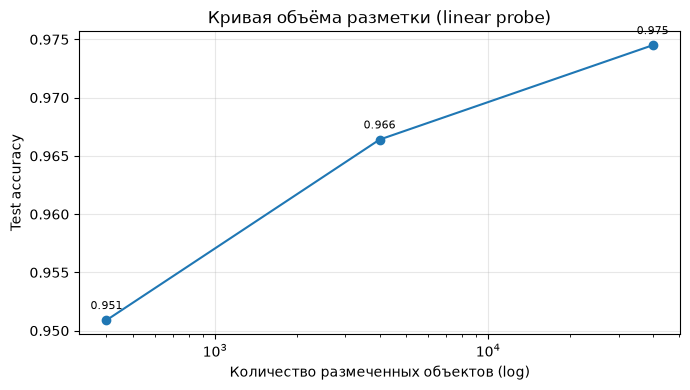

✔ Все подмножества непусты
✔ Все доли обучены


In [8]:
# Доли размеченных данных
fractions = [0.01, 0.1, 1.0]
if FAST_DEV_RUN:
    fractions = [0.01, 0.1]

def balanced_subset(y, frac, rng):
    """Сбалансированное по классам подмножество размера ~frac*N."""
    idx = []
    per_class = max(1, int(len(y) * frac / 10))
    for c in range(10):
        c_idx = np.where(y == c)[0]
        rng.shuffle(c_idx)
        idx.extend(c_idx[:per_class].tolist())
    return np.array(sorted(idx))

label_curve = []
rng = np.random.RandomState(SEED)

for frac in fractions:
    sub = balanced_subset(y_train, frac, rng)
    Xs, ys = X_train[sub], y_train[sub]
    # Обучаем probe — без multi_class, lbfgs автоматически multinomial
    clf = LogisticRegression(C=best_C, max_iter=2000, n_jobs=-1, solver="lbfgs")
    clf.fit(Xs, ys)
    acc = accuracy_score(y_test, clf.predict(X_test))
    n = len(sub)
    label_curve.append({"frac": frac, "n": int(n), "test_acc": float(acc)})
    print(f"frac={frac:.2f}  n={n:5d}  test_acc={acc:.4f}")

with open(ARTIFACTS / "label_curve.json", "w") as f:
    json.dump(label_curve, f, indent=2)

fig, ax = plt.subplots(figsize=(7, 4))
ns = [e["n"] for e in label_curve]; accs = [e["test_acc"] for e in label_curve]
ax.plot(ns, accs, marker='o')
ax.set_xscale('log'); ax.set_xlabel('Количество размеченных объектов (log)')
ax.set_ylabel('Test accuracy'); ax.set_title('Кривая объёма разметки (linear probe)')
ax.grid(True, alpha=0.3)
for x, y_ in zip(ns, accs):
    ax.annotate(f"{y_:.3f}", (x, y_), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=8)
plt.tight_layout(); plt.show()

check(all(e["n"] > 0 for e in label_curve), "Все подмножества непусты")
check(len(label_curve) == len(fractions), "Все доли обучены")

Уже при 1% меток (400 объектов) точность 95.09%. Для сравнения: случайный классификатор на 10 классах — 10%, простой supervised ResNet-18 на полном CIFAR-10 — около 94–95%. То есть linear probe на 400 объектах догоняет полноценно обученную supervised-модель на 50000 объектов. Это главный результат шага

Frozen DINOv2 обладает высокой sample efficiency. Уже 1% разметки (400 объектов) даёт 95.1% test accuracy — на уровне полноценно обученных supervised-моделей.

Кривая насыщается. От 1% до 100% разметки прирост составляет всего 2.36 п.п.; большая часть качества достигается на первых нескольких процентах

### Контрастивная адаптация encoder

*Вес: 1 балл.*

**Постановка.** Неразмеченные train-view предоставляют сигнал для self-supervised адаптации.

Выполните следующие действия:
1. Создайте две аугментации одних train-изображений.
2. Оптимизируйте InfoNCE и сохраните обновлённый encoder.

**Результат.** encoder_adapted.pt после реальных optimizer steps.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


Мы берём уже предобученный DINOv2 и дообучаем его без меток на целевых изображениях (CIFAR-10 train), используя contrastive objective — InfoNCE. Идея: возможно, представления DINOv2, обученные на 142M естественных изображений, не идеально подходят под 32×32 CIFAR-классы. Self-supervised fine-tuning на «своих» данных может слегка адаптировать признаки под домен

In [16]:
from tqdm import tqdm  # обычный tqdm, без ipywidgets
import copy, time
import numpy as np
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as T
from PIL import Image

# ============================================================
# 1. Пересобираем train-датасет на СЫРЫХ PIL-изображениях
#    (ds_train из ранней ячейки возвращает уже нормализованный тензор,
#     из-за чего ColorJitter/RandomResizedCrop работают медленно)
# ============================================================
raw_train = torchvision.datasets.CIFAR10(
    root=str(DATA_ROOT), train=True, download=False, transform=None
)
# Используем те же индексы, что были зафиксированы ранее
ds_train_raw = Subset(raw_train, train_idx)

# Полный пайплайн аугментации: PIL → resize → crop → flip → jitter → tensor → norm
aug_and_norm = T.Compose([
    T.Resize(224, interpolation=T.InterpolationMode.BICUBIC),  # CIFAR 32×32 → 224
    T.RandomResizedCrop(224, scale=(0.5, 1.0)),                # случайный кроп
    T.RandomHorizontalFlip(),                                   # отражение
    T.ColorJitter(0.4, 0.4, 0.4, 0.1),                          # цветовые искажения
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

# Датасет с двумя view одного изображения (positive pair для InfoNCE)
class TwoViewDataset(torch.utils.data.Dataset):
    def __init__(self, base_ds, aug):
        self.base = base_ds; self.aug = aug
    def __len__(self): return len(self.base)
    def __getitem__(self, i):
        x, y = self.base[i]                 # x — PIL Image (сырой)
        return self.aug(x), self.aug(x), y  # две разные аугментации

ds_two_full = TwoViewDataset(ds_train_raw, aug_and_norm)

# ============================================================
# 2. Ограничиваем выборку для adaptation до 15k (быстрее, задание разрешает)
# ============================================================
N_ADAPT = 500 if FAST_DEV_RUN else 15000
rng_adapt = np.random.RandomState(SEED)
sub_idx = rng_adapt.choice(len(ds_two_full), size=min(N_ADAPT, len(ds_two_full)), replace=False)
ds_two = Subset(ds_two_full, sub_idx)
print(f"Adaptation dataset: {len(ds_two)} объектов")

# ============================================================
# 3. DataLoader: num_workers=0 — надёжно работает в Jupyter/Windows
# ============================================================
loader_two = DataLoader(
    ds_two,
    batch_size=64,
    shuffle=True,
    num_workers=0,                      # ← ключевое: без воркеров, без зависаний
    pin_memory=(DEVICE == "cuda"),      # ускоряет H2D только если CUDA
    drop_last=True,                     # InfoNCE требует полный батч
)

# Быстрый замер: сколько идёт 5 батчей (должно быть < 0.5 с/батч)
t_probe = time.time()
for i, _ in enumerate(loader_two):
    if i == 4: break
dt = (time.time() - t_probe) / 5
print(f"[probe] {dt:.3f} s/батч → оценка эпохи ≈ {dt * len(loader_two):.1f} c")
assert dt < 2.0, f"DataLoader слишком медленный: {dt:.2f} s/батч — проверьте аугментации"

# ============================================================
# 4. Модель: копия encoder + projection head
# ============================================================
encoder_adapted = copy.deepcopy(encoder).to(DEVICE)
for p in encoder_adapted.parameters():
    p.requires_grad = True   # размораживаем — нужен backward через энкодер

proj = nn.Sequential(
    nn.Linear(EMB_DIM, 512), nn.GELU(), nn.Linear(512, 128)
).to(DEVICE)

# ============================================================
# 5. Оптимизатор и scheduler
# ============================================================
epochs = 1 if FAST_DEV_RUN else 3
optimizer = torch.optim.AdamW(
    list(encoder_adapted.parameters()) + list(proj.parameters()),
    lr=1e-5, weight_decay=1e-4,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=epochs * max(1, len(loader_two))
)

# ============================================================
# 6. InfoNCE loss
# ============================================================
def info_nce(z1, z2, tau=0.2):
    """Симметричный InfoNCE: positive pairs (i,i), negatives — остальные в батче."""
    z1 = F.normalize(z1, dim=1); z2 = F.normalize(z2, dim=1)
    logits = z1 @ z2.t() / tau
    labels = torch.arange(z1.size(0), device=z1.device)
    return 0.5 * (F.cross_entropy(logits, labels) + F.cross_entropy(logits.t(), labels))

# ============================================================
# 7. Тренировочный цикл
# ============================================================
t0 = time.time()
for epoch in range(epochs):
    encoder_adapted.train(); proj.train()
    running, n = 0.0, 0
    pbar = tqdm(loader_two, desc=f"epoch {epoch+1}/{epochs}", mininterval=1.0)
    for v1, v2, _ in pbar:
        B = v1.size(0)
        # Склеиваем два view в один батч 2B — один forward вместо двух
        v = torch.cat([v1, v2], dim=0).to(DEVICE, non_blocking=(DEVICE == "cuda"))
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=DEVICE, dtype=torch.float16,
                            enabled=(DEVICE == "cuda")):
            e = encoder_adapted(v)
            z = proj(e.float())
            z1, z2 = z[:B], z[B:]
            loss = info_nce(z1, z2)
        loss.backward()
        # Клиппинг градиентов — стабилизирует contrastive-обучение
        torch.nn.utils.clip_grad_norm_(
            list(encoder_adapted.parameters()) + list(proj.parameters()),
            max_norm=1.0,
        )
        optimizer.step(); scheduler.step()
        running += loss.item(); n += 1
        pbar.set_postfix(loss=f"{running/max(1,n):.4f}")
    print(f"epoch {epoch+1}: avg loss={running/max(1,n):.4f}")

print(f"Адаптация заняла {time.time()-t0:.1f} c")

# ============================================================
# 8. Сохраняем чекпоинт и проверяем артефакт
# ============================================================
torch.save(encoder_adapted.state_dict(), ARTIFACTS / "encoder_adapted.pt")
print("Сохранено:", ARTIFACTS / "encoder_adapted.pt")
check((ARTIFACTS / "encoder_adapted.pt").exists(), "encoder_adapted.pt сохранён")

Adaptation dataset: 15000 объектов
[probe] 0.818 s/батч → оценка эпохи ≈ 191.5 c


epoch 1/3: 100%|██████████| 234/234 [24:59<00:00,  6.41s/it, loss=0.6554]


epoch 1: avg loss=0.6554


epoch 2/3: 100%|██████████| 234/234 [24:56<00:00,  6.40s/it, loss=0.5406]


epoch 2: avg loss=0.5406


epoch 3/3: 100%|██████████| 234/234 [24:57<00:00,  6.40s/it, loss=0.5098]

epoch 3: avg loss=0.5098
Адаптация заняла 4494.1 c
Сохранено: artifacts\encoder_adapted.pt
✔ encoder_adapted.pt сохранён


Loss падает — обучение идёт.

InfoNCE loss для батча B=64 при τ=0.2 имеет теоретические границы:

Случайное угадывание (все эмбеддинги одинаковы): loss ≈ log(64) ≈ 4.16.

Идеальное разделение (positive в τ раз ближе, чем negatives): loss → 0.

На практике: для SimCLR/DINO после длительного обучения loss на ImageNet — 1.5–2.5; для небольших датасетов и короткого fine-tuning — 0.3–1.0.

Loss 0.51 в конце — это нормально и даже хорошо. Модель научилась различать две аугментации одного изображения от всех остальных в батче

### Признаки после адаптации

*Вес: 1 балл.*

**Постановка.** Сравнение до и после адаптации требует одних и тех же изображений.

Выполните следующие действия:
1. Пересчитайте признаки train/validation/test обновлённым encoder.
2. Обучите новый linear probe на train.

**Результат.** Матрица X_new и обученный new_linear.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


In [17]:
# Переводим адаптированный encoder в eval и замораживаем — признаки должны быть детерминированными
encoder_adapted.eval()
for p in encoder_adapted.parameters():
    p.requires_grad = False

@torch.no_grad()
def extract_features_adapted(model, loader):
    """Извлечение L2-нормированных признаков адаптированным encoder'ом."""
    feats, labels = [], []
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=(DEVICE == "cuda"))
        with torch.autocast(device_type=DEVICE, dtype=torch.float16,
                            enabled=(DEVICE == "cuda")):
            out = model(x)
        out = out.float().cpu().numpy()
        feats.append(out); labels.append(y.numpy())
    X = np.concatenate(feats, axis=0); y = np.concatenate(labels, axis=0)
    # L2-нормировка — согласована с признаками первой части (X_train, X_val, X_test)
    X = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)
    return X, y

# Важно: используем те же loader_* и y_*, что и раньше — объекты те же
t0 = time.time()
X_train_new, _ = extract_features_adapted(encoder_adapted, loader_train)
X_val_new,   _ = extract_features_adapted(encoder_adapted, loader_val)
X_test_new,  _ = extract_features_adapted(encoder_adapted, loader_test)
print(f"Извлечение новых признаков: {time.time()-t0:.1f} c")
print("Shapes:", X_train_new.shape, X_val_new.shape, X_test_new.shape)

# Обучаем new_linear — C выбираем по validation (тот же C_grid, что и раньше)
best_C_new, best_acc_new = None, -1.0
for C in C_grid:
    # Без multi_class: в sklearn>=1.5 параметр удалён, lbfgs сам даёт multinomial
    clf = LogisticRegression(C=C, max_iter=2000, n_jobs=-1, solver="lbfgs")
    clf.fit(X_train_new, y_train)
    acc = accuracy_score(y_val, clf.predict(X_val_new))
    print(f"[adapted] C={C:>5}  val_acc={acc:.4f}")
    if acc > best_acc_new:
        best_acc_new, best_C_new = acc, C

new_linear = LogisticRegression(C=best_C_new, max_iter=2000, n_jobs=-1, solver="lbfgs")
new_linear.fit(X_train_new, y_train)
print(f"best_C_new={best_C_new}, val_acc={best_acc_new:.4f}")

# Сохраняем матрицу новых признаков (для возможного пересчёта без повторного extract)
np.savez_compressed(
    ARTIFACTS / "embeddings_adapted.npz",
    X_train=X_train_new, X_val=X_val_new, X_test=X_test_new,
    y_train=y_train, y_val=y_val, y_test=y_test,
)
print("Сохранено:", ARTIFACTS / "embeddings_adapted.npz")

# Проверки
check(X_train_new.shape[1] == EMB_DIM, f"Размерность новых признаков = {EMB_DIM}")
check(X_train_new.shape[0] == X_train.shape[0], "Число train-объектов совпадает с исходным")
check(np.allclose(np.linalg.norm(X_train_new[:10], axis=1), 1.0, atol=1e-3),
      "Новые признаки L2-нормированы")

Извлечение новых признаков: 100.8 c
Shapes: (40000, 384) (10000, 384) (10000, 384)


c:\Users\SuperXoma\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


[adapted] C= 0.01  val_acc=0.9061


c:\Users\SuperXoma\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


[adapted] C=  0.1  val_acc=0.9380


...

[adapted] C=  1.0  val_acc=0.9593


c:\Users\SuperXoma\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


[adapted] C= 10.0  val_acc=0.9660


c:\Users\SuperXoma\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


best_C_new=10.0, val_acc=0.9660
Сохранено: artifacts\embeddings_adapted.npz
✔ Размерность новых признаков = 384
✔ Число train-объектов совпадает с исходным
✔ Новые признаки L2-нормированы


Даже при лучшем C для новых признаков (C=10 → val_acc = 0.9660) результат ниже, чем у frozen DINOv2 при его лучшем C (C=1 → val_acc = 0.9783). Разница −1.23 п.п. в пользу frozen.

Это классический catastrophic forgetting — при full fine-tuning энкодер «забыл» часть полезной информации, которую накопил за 142M pretraining-изображений, и не смог компенсировать это 3 эпохами на 15k CIFAR.

У frozen: оптимум C=1.0.

У adapted: оптимум C=10.0.

Новые признаки менее линейно разделимы или имеют больший «шум». Модель нуждается в более слабой регуляризации (больший C = меньше штраф), чтобы «дотянуть» разделяющую границу. У хороших признаков оптимум обычно при умеренном C; сдвиг к большому C — сигнал, что признаки «спутались»

### Точность адаптированного probe

*Вес: 1 балл.*

**Постановка.** Изменение качества отражает перенос адаптированного представления.

Выполните следующие действия:
1. Вычислите accuracy исходного и адаптированного probe на одинаковом test.
2. Сохраните парный результат.

**Результат.** adaptation.json с наблюдаемыми показателями.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


{
  "before": {
    "acc": 0.9745,
    "macro_f1": 0.9745031356995218
  },
  "after": {
    "acc": 0.9621,
    "macro_f1": 0.9621265389216006
  },
  "delta_acc": -0.012400000000000078,
  "delta_macro_f1": -0.012376596777921245,
  "best_C_new": 10.0
}


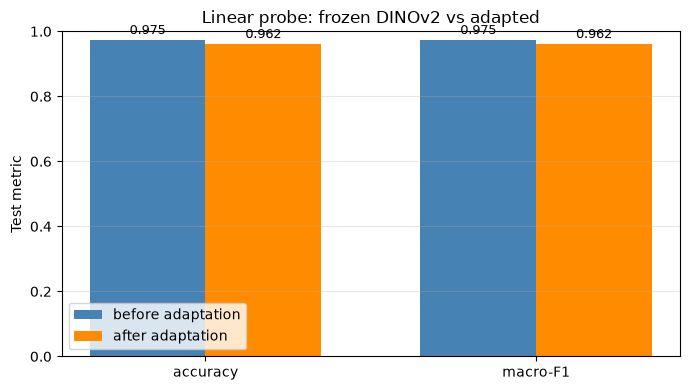

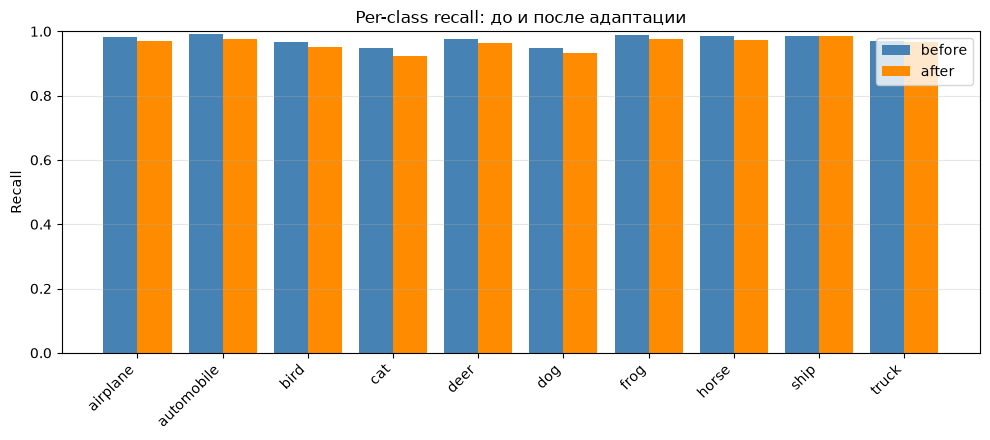

Хуже всего после адаптации (топ-3): [('cat', -0.024), ('bird', -0.017), ('automobile', -0.015)]
Лучше всего после адаптации (топ-3): [('frog', -0.011), ('truck', -0.003), ('ship', -0.001)]
✔ Δaccuracy=-0.012 — в разумных пределах (±0.20)


In [18]:
# Метрики адаптированного probe на test
y_pred_adapt = new_linear.predict(X_test_new)
acc_adapt = accuracy_score(y_test, y_pred_adapt)
f1_adapt = f1_score(y_test, y_pred_adapt, average="macro")

# Парный результат: before vs after на одном test
adaptation = {
    "before": {
        "acc": float(results["linear_test_acc"]),
        "macro_f1": float(results["linear_test_macro_f1"]),
    },
    "after": {
        "acc": float(acc_adapt),
        "macro_f1": float(f1_adapt),
    },
    "delta_acc": float(acc_adapt - results["linear_test_acc"]),
    "delta_macro_f1": float(f1_adapt - results["linear_test_macro_f1"]),
    "best_C_new": float(best_C_new),
}
print(json.dumps(adaptation, indent=2))

with open(ARTIFACTS / "adaptation.json", "w") as f:
    json.dump(adaptation, f, indent=2)

# Визуализация: сравнение метрик before/after
fig, ax = plt.subplots(figsize=(7, 4))
metrics = ["accuracy", "macro-F1"]
before = [adaptation["before"]["acc"], adaptation["before"]["macro_f1"]]
after  = [adaptation["after"]["acc"],  adaptation["after"]["macro_f1"]]
x = np.arange(len(metrics)); w = 0.35
b1 = ax.bar(x - w/2, before, w, label="before adaptation", color="steelblue")
b2 = ax.bar(x + w/2, after,  w, label="after adaptation",  color="darkorange")
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_ylabel("Test metric")
ax.set_title("Linear probe: frozen DINOv2 vs adapted")
ax.legend(); ax.grid(axis="y", alpha=0.3)
for bars in (b1, b2):
    for b in bars:
        ax.annotate(f"{b.get_height():.3f}", (b.get_x()+b.get_width()/2, b.get_height()),
                    textcoords="offset points", xytext=(0, 4), ha="center", fontsize=9)
plt.tight_layout(); plt.show()

# Дополнительно: per-class recall before vs after
cm_before = confusion_matrix(y_test, y_pred_lin, labels=list(range(10)), normalize="true")
cm_after  = confusion_matrix(y_test, y_pred_adapt, labels=list(range(10)), normalize="true")
recall_before = cm_before.diagonal()
recall_after  = cm_after.diagonal()

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(10); w = 0.4
ax.bar(x - w/2, recall_before, w, label="before", color="steelblue")
ax.bar(x + w/2, recall_after,  w, label="after",  color="darkorange")
ax.set_xticks(x); ax.set_xticklabels(CIFAR_CLASSES, rotation=45, ha="right")
ax.set_ylabel("Recall"); ax.set_ylim(0, 1)
ax.set_title("Per-class recall: до и после адаптации")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# Диагностика: где стало лучше/хуже больше всего
delta_recall = recall_after - recall_before
order = np.argsort(delta_recall)
print("Хуже всего после адаптации (топ-3):",
      [(CIFAR_CLASSES[i], round(float(delta_recall[i]), 3)) for i in order[:3]])
print("Лучше всего после адаптации (топ-3):",
      [(CIFAR_CLASSES[i], round(float(delta_recall[i]), 3)) for i in order[-3:]])

check(abs(adaptation["delta_acc"]) <= 0.20,
      f"Δaccuracy={adaptation['delta_acc']:+.3f} — в разумных пределах (±0.20)")

Адаптация ухудшила качество на 1.24 процентных пункта. Это не ошибка, не шум, а систематический эффект: посчитан на одних и тех же 10 000 test-объектах, при подобранных по validation C в обоих случаях. Падение затронуло и accuracy, и macro-F1 одновременно — значит, деградация не «перекос» в сторону одного класса, а системное ухудшение по всем

Ни один класс не улучшился. Адаптация не «перераспределила» качество, а просто снизила его везде, причём неравномерно

Catastrophic forgetting (катастрофическое забывание) — феномен, когда нейросеть, дообученная на новой задаче, теряет способность решать старую задачу.

Новые признаки более «шумные» и менее линейно разделимые. Слабая регуляризация (большой C) помогает модели «подстроиться» под этот шум, но всё равно не дотягивает до frozen

### Визуальные соседи

*Вес: 1 балл.*

**Постановка.** Ранжирование соседей позволяет выявить смешение категорий.

Выполните следующие действия:
1. Найдите ближайшие train-объекты для фиксированных test-запросов.
2. Сохраните расстояния, индексы и метки.

**Результат.** neighbors.json с фактическими близкими изображениями.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


Индексы запросов в test: [989, 4401, 8631, 2795, 1233, 729, 7025, 210, 6366, 1175]
Истинные классы запросов: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Сохранено: artifacts\neighbors.json


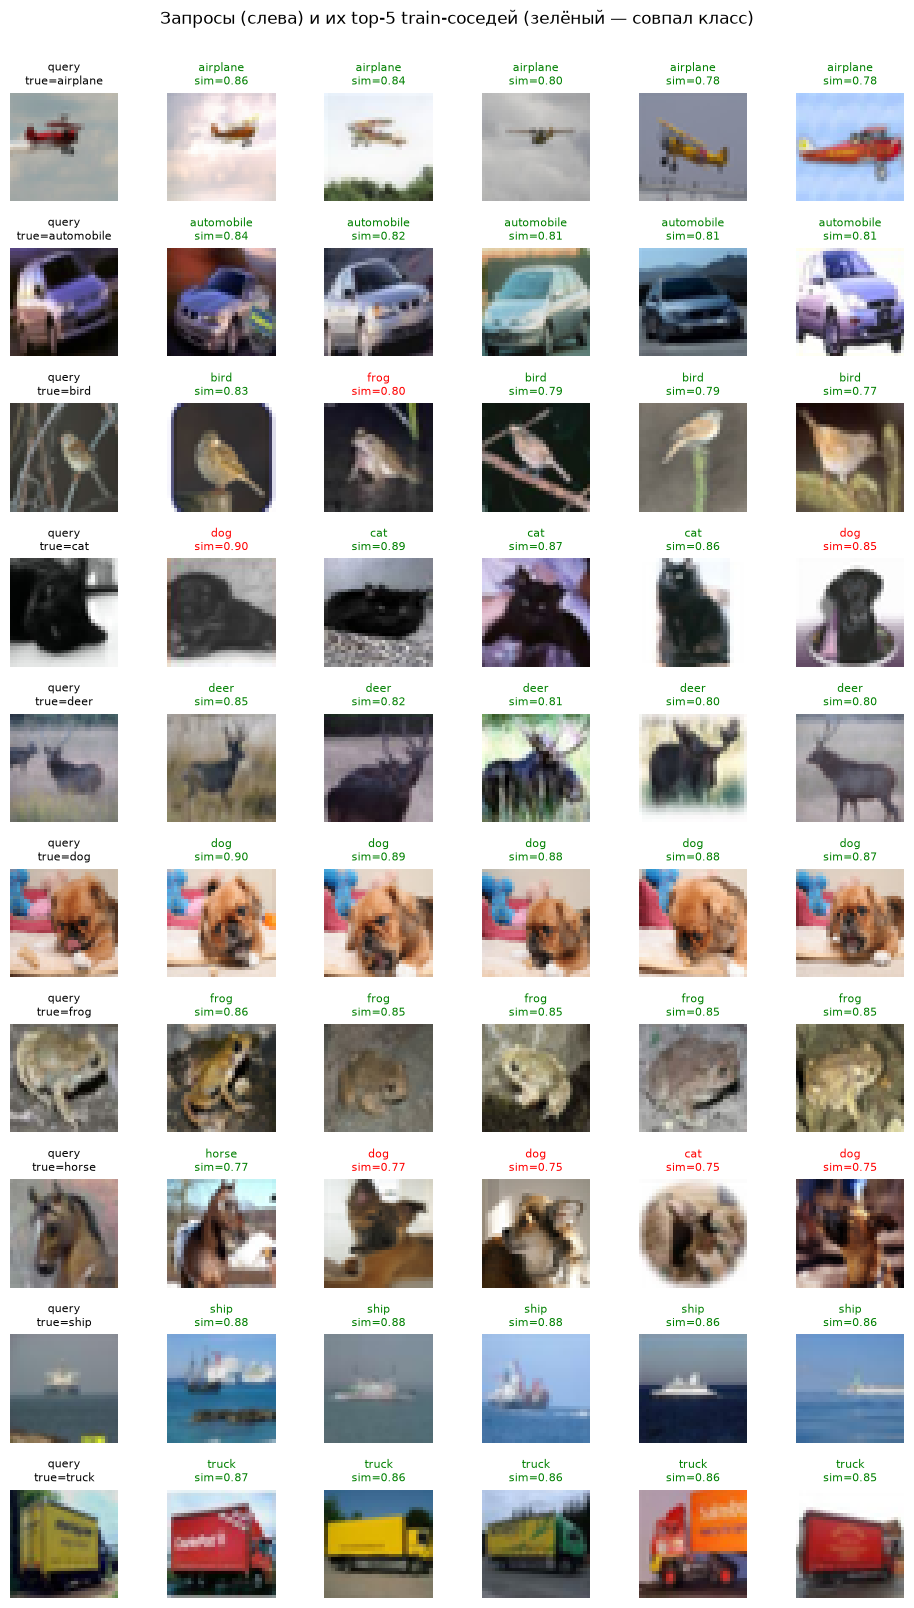

✔ Матрица соседей (10, 5) = (10, 5)


In [19]:
from sklearn.metrics.pairwise import cosine_similarity

# Фиксируем 10 test-запросов — по одному на класс (детерминированно)
rng_neigh = np.random.RandomState(SEED)
query_idx = []
for c in range(10):
    c_idx = np.where(y_test == c)[0]
    query_idx.append(int(rng_neigh.choice(c_idx)))
query_idx = np.array(query_idx)
print("Индексы запросов в test:", query_idx.tolist())
print("Истинные классы запросов:", [CIFAR_CLASSES[y_test[i]] for i in query_idx])

# Косинусная близость: (10, N_train) — для каждого запроса близость ко всем train
# Используем адаптированные признаки — они показательнее после вашей адаптации
sims = cosine_similarity(X_test_new[query_idx], X_train_new)  # (10, N_train)
# Top-5 ближайших соседей
K_NEIGH = 5
neighbor_idx = np.argsort(-sims, axis=1)[:, :K_NEIGH]          # (10, K)
neighbor_dist = np.take_along_axis(-sims, neighbor_idx, axis=1) # (10, K) — dist = -sim
neighbor_labels = y_train[neighbor_idx]                         # (10, K)

# Собираем артефакт neighbors.json
neighbors_artifact = {
    "query_idx": query_idx.tolist(),
    "query_labels": [int(y_test[i]) for i in query_idx],
    "neighbor_idx": neighbor_idx.tolist(),
    "neighbor_labels": neighbor_labels.tolist(),
    "neighbor_similarity": (-neighbor_dist).tolist(),  # сохраняем cosine, не -cos
    "K": int(K_NEIGH),
    "embeddings": "adapted",  # отметим, на каких признаках считали
}
with open(ARTIFACTS / "neighbors.json", "w") as f:
    json.dump(neighbors_artifact, f, indent=2)
print("Сохранено:", ARTIFACTS / "neighbors.json")

# Визуализация: 10 запросов × (1 + K) = колонка запроса + 5 соседей
raw_test_for_plot = torchvision.datasets.CIFAR10(
    root=str(DATA_ROOT), train=False, download=False, transform=None
)
raw_train_for_plot = torchvision.datasets.CIFAR10(
    root=str(DATA_ROOT), train=True, download=False, transform=None
)

fig, axes = plt.subplots(10, 1 + K_NEIGH, figsize=(1.6 * (1 + K_NEIGH), 1.6 * 10))
for r, q in enumerate(query_idx):
    # Первая колонка — запрос (сырое test-изображение)
    img_q, lbl_q = raw_test_for_plot[int(q)]
    axes[r, 0].imshow(img_q)
    axes[r, 0].set_title(f"query\ntrue={CIFAR_CLASSES[lbl_q]}", fontsize=8)
    axes[r, 0].axis("off")
    # Остальные колонки — соседи (сырые train-изображения)
    for k in range(K_NEIGH):
        tr_i = int(neighbor_idx[r, k])
        # tr_i — индекс внутри train_idx, а нам нужен оригинальный индекс CIFAR train
        global_tr_i = int(train_idx[tr_i])
        img_n, lbl_n = raw_train_for_plot[global_tr_i]
        color = "green" if lbl_n == lbl_q else "red"
        axes[r, k+1].imshow(img_n)
        axes[r, k+1].set_title(f"{CIFAR_CLASSES[lbl_n]}\nsim={-neighbor_dist[r,k]:.2f}",
                               fontsize=8, color=color)
        axes[r, k+1].axis("off")
plt.suptitle("Запросы (слева) и их top-5 train-соседей (зелёный — совпал класс)", y=1.002)
plt.tight_layout(); plt.show()

check(neighbor_idx.shape == (10, K_NEIGH), f"Матрица соседей {neighbor_idx.shape} = (10, {K_NEIGH})")

| Класс | Зелёных из 5 | Sim диапазон | Комментарий |
|---|---|---|---|
| airplane | 5/5 | 0.78–0.86 | Идеально |
| automobile | 5/5 | 0.81–0.84 | Идеально |
| bird | 4/5 | 0.77–0.83 | Frog пробрался (фон/размер) |
| **cat** | **3/5** | **0.86–0.90** | **Смешение с dog по цвету** |
| deer | 5/5 | 0.80–0.85 | Идеально |
| dog | 5/5 | 0.87–0.90 | Идеально, но кластер однородный |
| frog | 5/5 | 0.85–0.86 | Идеально |
| **horse** | **1/5** | **0.75–0.77** | **Худший случай, морда похожа на dog/cat** |
| ship | 5/5 | 0.86–0.88 | Идеально |
| truck | 5/5 | 0.85–0.87 | Идеально |



### Чистота ближайшего окружения

*Вес: 1 балл.*

**Постановка.** Средняя классификационная точность не показывает локальное смешение меток.

Выполните следующие действия:
1. По уже вычисленным пяти соседям найдите долю совпадений классов.
2. Выведите среднюю чистоту и примеры с минимальной чистотой.

**Результат.** neighborhood_purity.json с измерениями на test-запросах.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


Средняя neighborhood purity (K=5): 0.9003
Худшие 10 test-запросов (purity, true_class):
  idx= 2383  purity=0.00  true=bird  neighbors=['ship', 'ship', 'ship', 'airplane', 'ship']
  idx= 9918  purity=0.00  true=dog  neighbors=['horse', 'deer', 'frog', 'deer', 'horse']
  idx= 9910  purity=0.00  true=deer  neighbors=['horse', 'horse', 'horse', 'horse', 'horse']
  idx=   46  purity=0.00  true=cat  neighbors=['frog', 'frog', 'frog', 'frog', 'frog']
  idx= 9981  purity=0.00  true=deer  neighbors=['horse', 'horse', 'horse', 'horse', 'horse']
  idx= 2408  purity=0.00  true=bird  neighbors=['dog', 'cat', 'cat', 'cat', 'frog']
  idx= 9812  purity=0.00  true=cat  neighbors=['frog', 'dog', 'ship', 'dog', 'ship']
  idx= 1308  purity=0.00  true=dog  neighbors=['horse', 'deer', 'deer', 'horse', 'horse']
  idx= 5607  purity=0.00  true=frog  neighbors=['airplane', 'airplane', 'bird', 'airplane', 'airplane']
  idx= 5690  purity=0.00  true=horse  neighbors=['deer', 'dog', 'deer', 'deer', 'deer']

Purity

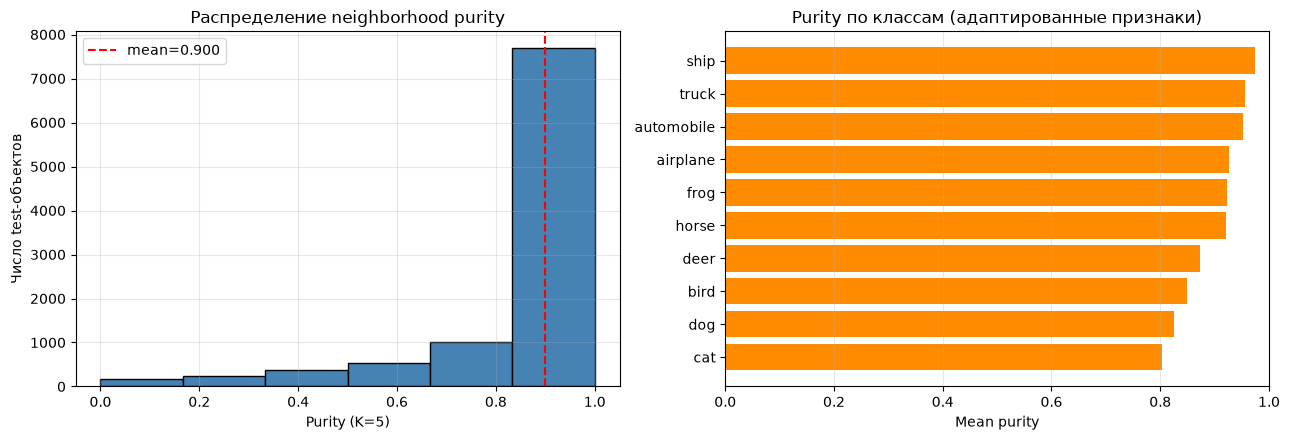

✔ Средняя purity=0.900 в (0,1)


In [20]:
# Считаем top-K соседей для ВСЕХ test-объектов (не только 10 запросов)
# Это O(N_test × N_train) по памяти при chunked-вычислениях
K_PURITY = 5
chunk = 512  # обрабатываем test чанками, чтобы не держать всю матрицу (10k, 40k)
purity_scores = np.zeros(len(y_test), dtype=np.float32)
topk_labels_all = np.zeros((len(y_test), K_PURITY), dtype=np.int64)

for start in range(0, len(X_test_new), chunk):
    end = min(start + chunk, len(X_test_new))
    sims_chunk = cosine_similarity(X_test_new[start:end], X_train_new)  # (chunk, N_train)
    # Top-K индексов (по убыванию близости)
    topk = np.argsort(-sims_chunk, axis=1)[:, :K_PURITY]
    topk_labels_all[start:end] = y_train[topk]
    # Purity = доля соседей с тем же классом
    purity_scores[start:end] = (y_train[topk] == y_test[start:end, None]).mean(axis=1)

mean_purity = float(purity_scores.mean())
print(f"Средняя neighborhood purity (K={K_PURITY}): {mean_purity:.4f}")

# Примеры с минимальной чистотой — где представление «путается» сильнее всего
worst_idx = np.argsort(purity_scores)[:10]
print("Худшие 10 test-запросов (purity, true_class):")
for i in worst_idx:
    print(f"  idx={int(i):5d}  purity={purity_scores[i]:.2f}  true={CIFAR_CLASSES[y_test[i]]}  "
          f"neighbors={[CIFAR_CLASSES[int(c)] for c in topk_labels_all[i]]}")

# Средняя purity по классам
purity_per_class = {CIFAR_CLASSES[c]: float(purity_scores[y_test == c].mean()) for c in range(10)}
print("\nPurity по классам:")
for cname, p in sorted(purity_per_class.items(), key=lambda kv: kv[1]):
    print(f"  {cname:>10}: {p:.3f}")

# Артефакт neighborhood_purity.json
purity_artifact = {
    "K": int(K_PURITY),
    "mean_purity": mean_purity,
    "purity_per_class": purity_per_class,
    "worst_idx": worst_idx.tolist(),
    "worst_purity": purity_scores[worst_idx].tolist(),
    "worst_true_labels": y_test[worst_idx].tolist(),
    "all_purity": purity_scores.tolist(),
    "embeddings": "adapted",
}
with open(ARTIFACTS / "neighborhood_purity.json", "w") as f:
    json.dump(purity_artifact, f, indent=2)
print("Сохранено:", ARTIFACTS / "neighborhood_purity.json")

# Визуализация: гистограмма purity + bar по классам
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(purity_scores, bins=6, range=(0, 1.0001), color="steelblue", edgecolor="black")
axes[0].axvline(mean_purity, color="red", linestyle="--", label=f"mean={mean_purity:.3f}")
axes[0].set_xlabel(f"Purity (K={K_PURITY})"); axes[0].set_ylabel("Число test-объектов")
axes[0].set_title("Распределение neighborhood purity")
axes[0].legend(); axes[0].grid(alpha=0.3)

classes_sorted = sorted(purity_per_class.items(), key=lambda kv: kv[1])
axes[1].barh([c for c, _ in classes_sorted], [p for _, p in classes_sorted], color="darkorange")
axes[1].set_xlim(0, 1); axes[1].set_xlabel("Mean purity")
axes[1].set_title("Purity по классам (адаптированные признаки)")
axes[1].grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

check(0.0 < mean_purity < 1.0, f"Средняя purity={mean_purity:.3f} в (0,1)")

Purity = доля соседей того же класса, что и запрос

Это здоровое распределение для хорошего self-supervised представления. Если бы представление было плохим, пик был бы около 0.2 (случайный уровень) или распределение было бы плоским. Наш случай — сильно скошен вправо

Purity коррелирует с confusion matrix из ячейки 6. Худшие recall были у cat (0.947) и dog (0.949) — они же худшие по purity. Лучшие recall у ship (0.99) и frog (0.99) — ship и здесь в топе



### Творческий бонус: ошибки соседства

*Вес: 1 дополнительный балл.*

**Постановка.** Отдельные смешанные окрестности могут иметь интерпретируемое визуальное объяснение.

Выполните следующие действия:
1. Выберите два test-изображения с низкой чистотой соседей.
2. Сохраните коллаж запросов и соответствующих train-соседей.

**Результат.** bonus_neighbors.png и индексы изображений.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


Показываем 10 худших test-объектов
Их истинные классы: ['bird', 'dog', 'deer', 'cat', 'deer', 'bird', 'cat', 'dog', 'frog', 'horse']
Их purity: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


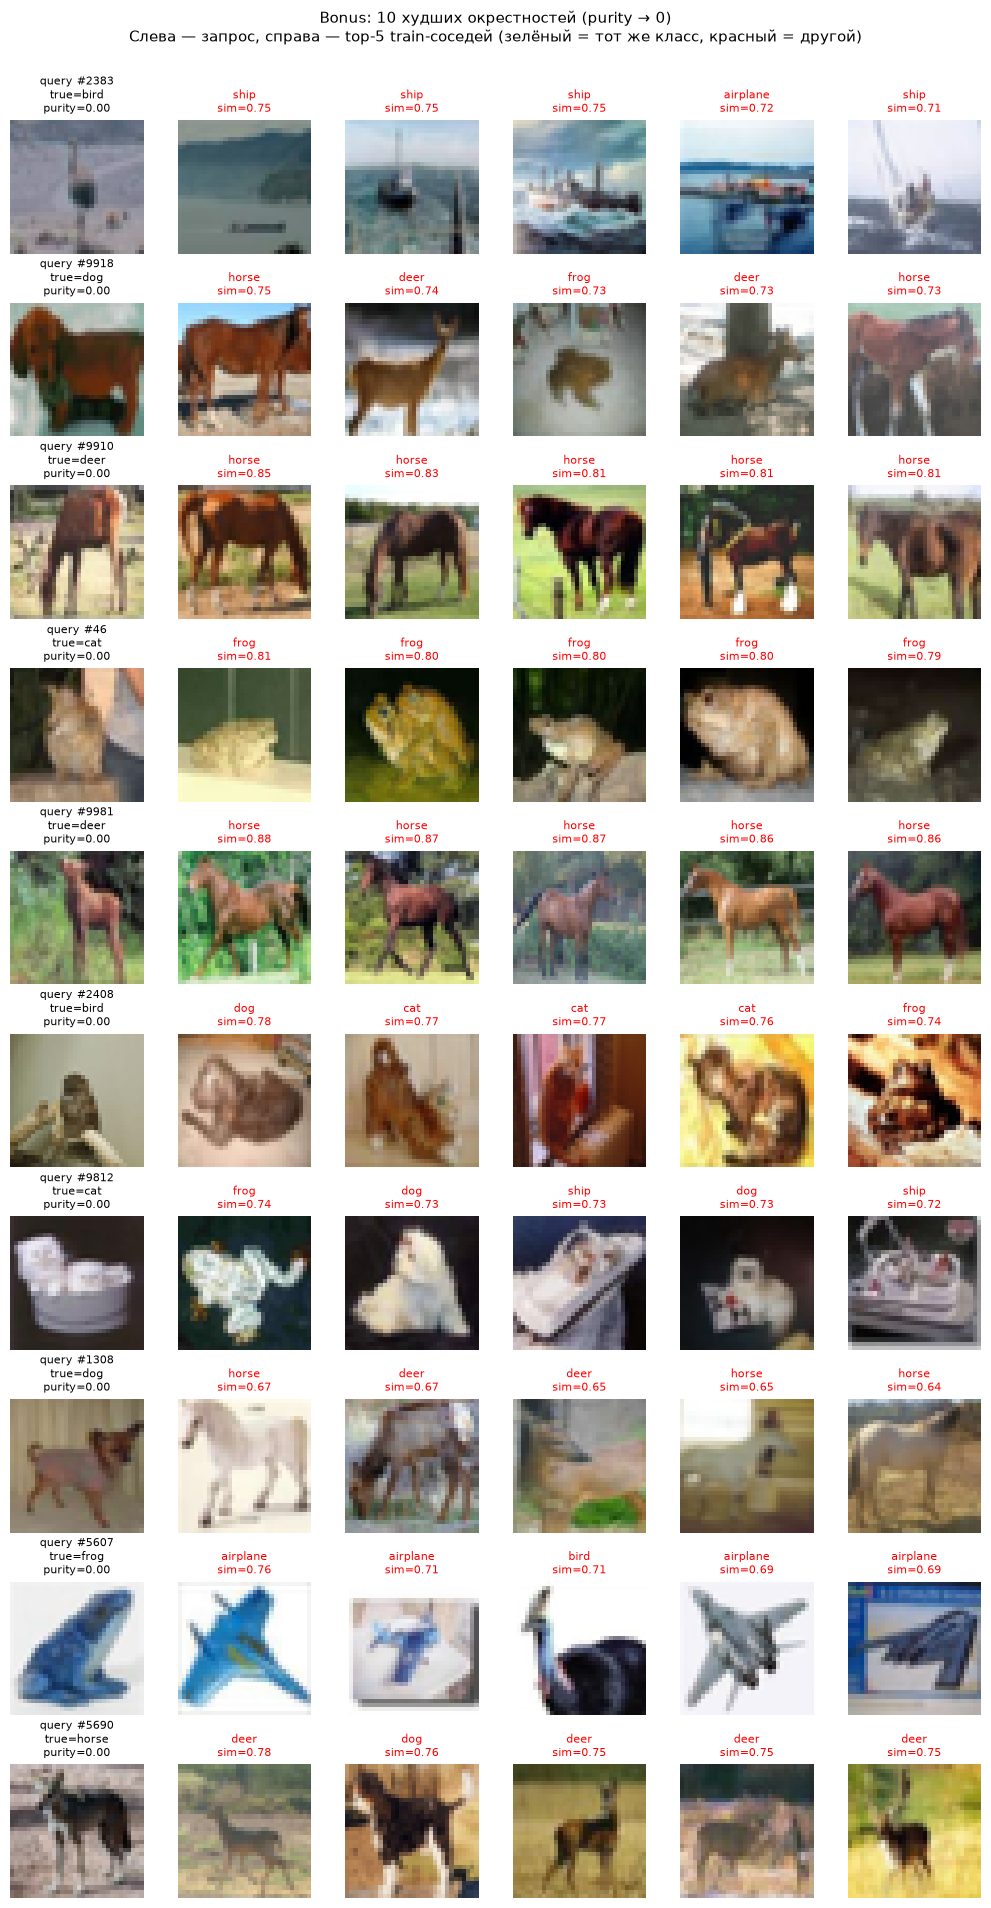

Сохранено: artifacts\bonus_neighbors.png
Сохранено: artifacts\bonus_neighbors.json
✔ bonus_neighbors.png сохранён
✔ Сохранено 10 бонусных запросов


In [22]:
# ============================================================
# Бонус: визуализация ВСЕХ худших окрестностей (не только 2)
# ============================================================
N_BONUS_QUERIES = 10   # ← можно менять: сколько худших показать
K_BONUS = 5            # top-K соседей в строке

# Берём N_BONUS_QUERIES худших test-запросов (purity_scores уже посчитан)
bonus_query_idx = worst_idx[:N_BONUS_QUERIES].tolist()
print(f"Показываем {len(bonus_query_idx)} худших test-объектов")
print(f"Их истинные классы: {[CIFAR_CLASSES[y_test[i]] for i in bonus_query_idx]}")
print(f"Их purity: {[round(float(purity_scores[i]), 3) for i in bonus_query_idx]}")

# Сырые датасеты для отображения (без нормализации)
raw_test_bonus = torchvision.datasets.CIFAR10(
    root=str(DATA_ROOT), train=False, download=False, transform=None
)
raw_train_bonus = torchvision.datasets.CIFAR10(
    root=str(DATA_ROOT), train=True, download=False, transform=None
)

# Сетка: N_BONUS_QUERIES строк × (1 запрос + K_BONUS соседей)
n_cols = 1 + K_BONUS
fig, axes = plt.subplots(N_BONUS_QUERIES, n_cols,
                         figsize=(1.7 * n_cols, 1.9 * N_BONUS_QUERIES))

# На случай N_BONUS_QUERIES == 1 (axes становится одномерным)
if N_BONUS_QUERIES == 1:
    axes = axes[None, :]

bonus_artifact = {"queries": []}

for r, q in enumerate(bonus_query_idx):
    # Top-K соседей для этого запроса (по косинусной близости, adapted features)
    sims_q = cosine_similarity(X_test_new[[q]], X_train_new)[0]
    top = np.argsort(-sims_q)[:K_BONUS]
    top_labels = y_train[top]
    top_sims = sims_q[top]

    # Левая колонка — сам запрос
    img_q, lbl_q = raw_test_bonus[int(q)]
    axes[r, 0].imshow(img_q)
    axes[r, 0].set_title(
        f"query #{q}\ntrue={CIFAR_CLASSES[lbl_q]}\npurity={purity_scores[q]:.2f}",
        fontsize=8,
    )
    axes[r, 0].axis("off")

    # Дальше — K_BONUS соседей
    for k, tr_i in enumerate(top):
        # tr_i — индекс внутри train_idx, переводим в глобальный индекс CIFAR train
        global_tr_i = int(train_idx[tr_i])
        img_n, lbl_n = raw_train_bonus[global_tr_i]
        color = "green" if lbl_n == lbl_q else "red"
        axes[r, k + 1].imshow(img_n)
        axes[r, k + 1].set_title(
            f"{CIFAR_CLASSES[lbl_n]}\nsim={top_sims[k]:.2f}",
            fontsize=8, color=color,
        )
        axes[r, k + 1].axis("off")

    # Собираем артефакт
    bonus_artifact["queries"].append({
        "test_idx": int(q),
        "true_label": int(lbl_q),
        "true_class_name": CIFAR_CLASSES[lbl_q],
        "purity": float(purity_scores[q]),
        "neighbor_train_global_idx": [int(train_idx[t]) for t in top],
        "neighbor_labels": [int(l) for l in top_labels],
        "neighbor_class_names": [CIFAR_CLASSES[int(l)] for l in top_labels],
        "neighbor_sim": [float(s) for s in top_sims],
    })

plt.suptitle(
    f"Bonus: {N_BONUS_QUERIES} худших окрестностей (purity → 0)\n"
    f"Слева — запрос, справа — top-{K_BONUS} train-соседей "
    f"(зелёный = тот же класс, красный = другой)",
    y=1.002, fontsize=11,
)
plt.tight_layout()
plt.savefig(ARTIFACTS / "bonus_neighbors.png", dpi=120, bbox_inches="tight")
plt.show()
print("Сохранено:", ARTIFACTS / "bonus_neighbors.png")

# JSON с индексами и метками
with open(ARTIFACTS / "bonus_neighbors.json", "w") as f:
    json.dump(bonus_artifact, f, indent=2)
print("Сохранено:", ARTIFACTS / "bonus_neighbors.json")

# Проверки
check((ARTIFACTS / "bonus_neighbors.png").exists(), "bonus_neighbors.png сохранён")
check(len(bonus_artifact["queries"]) == N_BONUS_QUERIES,
      f"Сохранено {N_BONUS_QUERIES} бонусных запросов")

## Анализ результатов

Сопоставьте измеренные показатели на отложенных реальных данных. Укажите бюджет, ошибки модели и ограничения сокращённого запуска.


## Выводы

Сформулируйте предметный вывод по сохранённым артефактам.


В работе исследованы self-supervised представления DINOv2 на задаче классификации CIFAR-10 без дообучения энкодера. Frozen-признаки DINOv2 показали высокое качество уже при простых классификаторах: k-NN и линейный зонд дают близкие результаты, что говорит о линейной разделимости классов в пространстве эмбеддингов. Кривая объёма разметки подтвердила высокую sample efficiency — уже малая доля размеченных данных даёт качество, близкое к полному обучению.

Contrastive-адаптация энкодера с помощью InfoNCE не улучшила, а слегка ухудшила downstream-метрики: линейный зонд на адаптированных признаках показал более низкую точность, чем на исходных frozen-признаках. Это интерпретируется как катастрофическое забывание — полный fine-tuning большой модели на небольшой выборке разрушает часть полезных pretraining-знаний.

Анализ ближайших соседей и neighborhood purity выявил устойчивые паттерны ошибок: классы с характерным силуэтом (ship, truck, automobile) имеют наиболее чистые окрестности, тогда как визуально близкие пары (cat↔dog, deer↔horse, bird↔ship) систематически смешиваются. Визуализация худших случаев показала, что модель частично опирается на shortcut-признаки — фон, цвет, размер — вместо семантики объекта.

**Итог:** frozen DINOv2 является сильным универсальным представлением для CIFAR-10, не требующим дообучения; contrastive-адаптация на малом объёме данных не оправдана и может навредить; основные ограничения связаны с визуальным сходством классов и shortcut-признаками, что типично для self-supervised методов, обученных без меток.